In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go

In [13]:
df = px.data.iris()

df.head()

,sepal_length,sepal_width,petal_length,petal_width,species,species_id
0,5.1,3.5,1.4,0.2,setosa,1
1,4.9,3.0,1.4,0.2,setosa,1
2,4.7,3.2,1.3,0.2,setosa,1
3,4.6,3.1,1.5,0.2,setosa,1
4,5.0,3.6,1.4,0.2,setosa,1


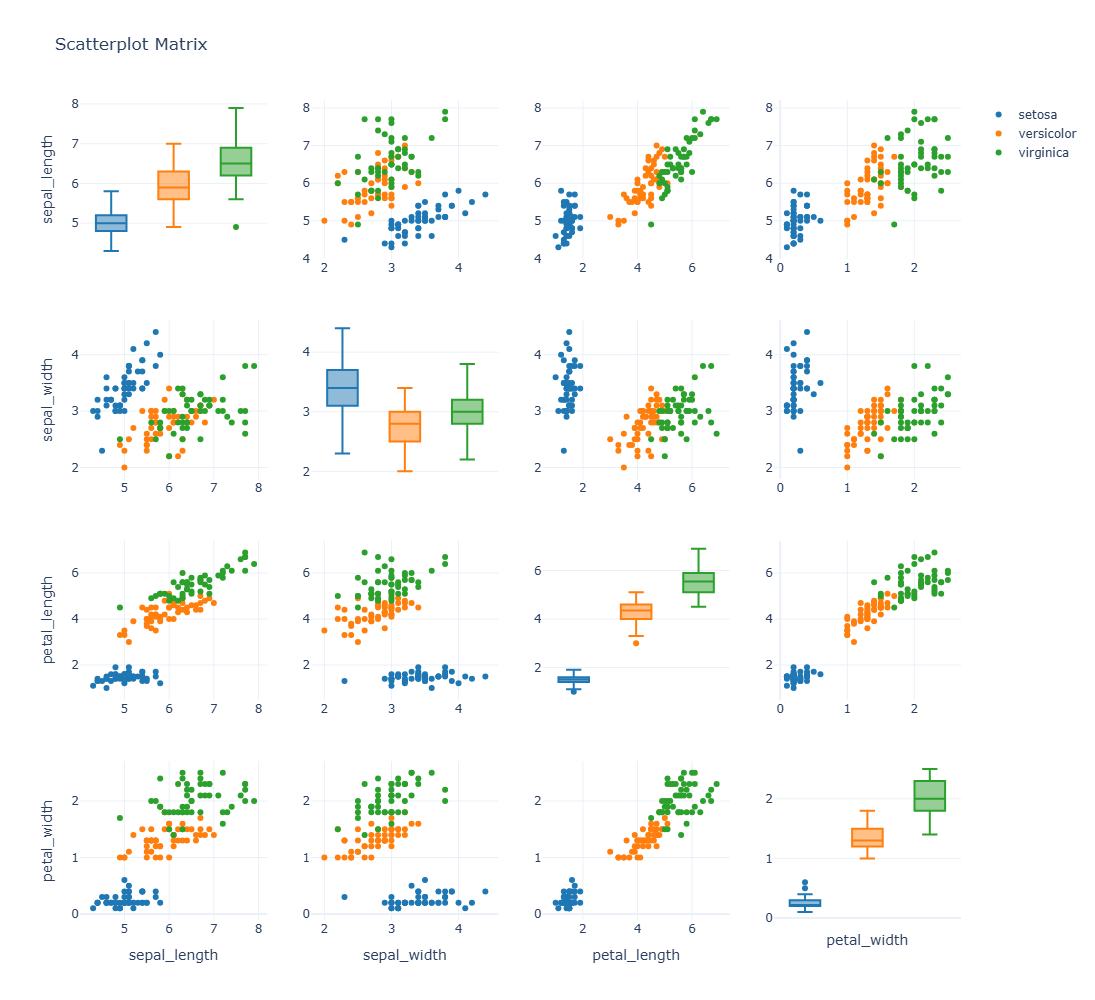

In [224]:
import plotly.figure_factory as ff

#fig = px.scatter_matrix(df[features + ['species']], color = 'species', template = 'plotly_white')
fig = ff.create_scatterplotmatrix(
    df[features + ['species']],
    diag = 'box',
    index = 'species',
    height = 1000,
    width = 1000
)

fig.update_layout(template = 'plotly_white')

fig.show()

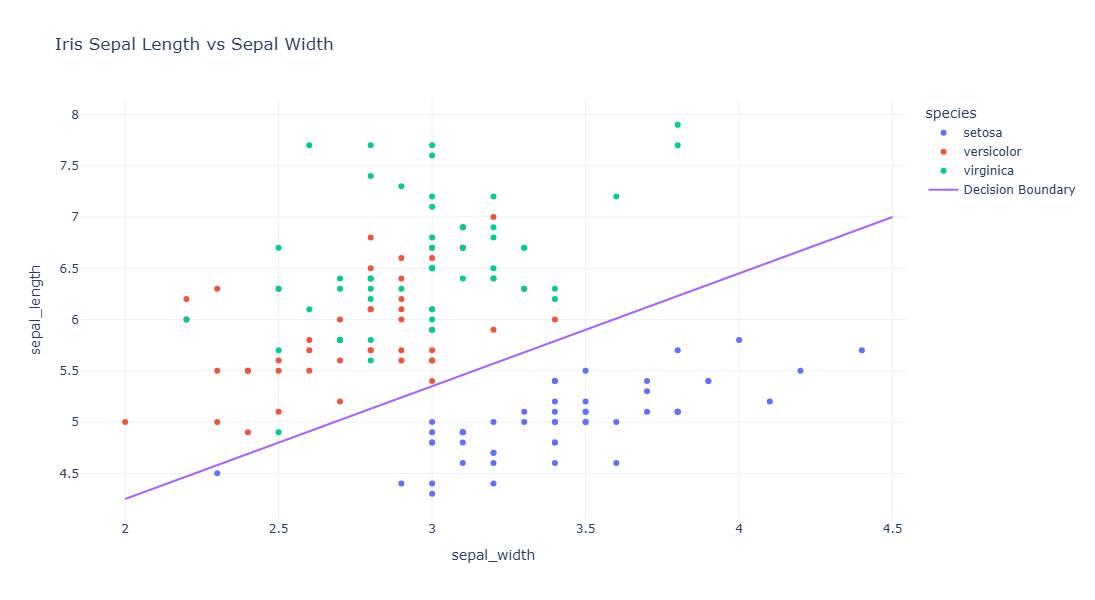

In [21]:
fig = px.scatter(df, x = 'sepal_width', y = 'sepal_length', color = 'species', 
                 title = 'Iris Sepal Length vs Sepal Width', template = 'plotly_white')

fig.update_layout(
    width = 800, height = 600
)

line_x = [2, 4.5]
line_y = [4.25, 7]

fig.add_trace(go.Scatter(
    x = line_x,
    y = line_y,
    mode = 'lines',
    name = 'Decision Boundary'
))

fig.show()

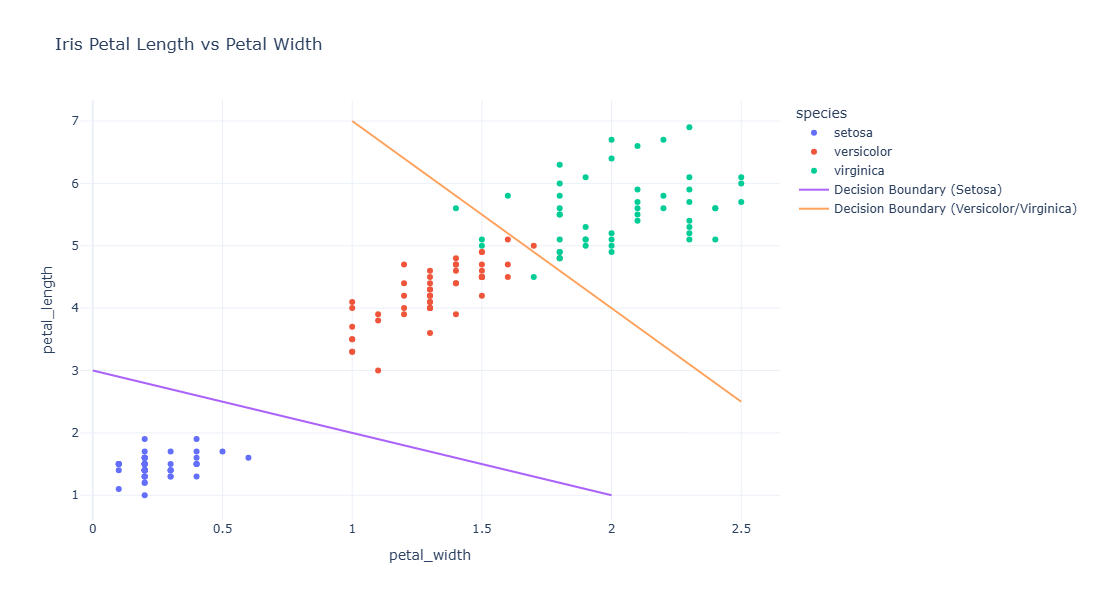

In [29]:
fig = px.scatter(df, x = 'petal_width', y = 'petal_length', color = 'species', 
                 title = 'Iris Petal Length vs Petal Width', template = 'plotly_white')

fig.update_layout(
    width = 800, height = 600
)

line_x = [0, 2]
line_y = [3, 1]

fig.add_trace(go.Scatter(
    x = line_x,
    y = line_y,
    mode = 'lines',
    name = 'Decision Boundary (Setosa)'
))

line_x = [1, 2.5]
line_y = [7, 2.5]

fig.add_trace(go.Scatter(
    x = line_x,
    y = line_y,
    mode = 'lines',
    name = 'Decision Boundary (Versicolor/Virginica)'
))

fig.show()

In [149]:
display(df[['species', 'species_id']].drop_duplicates())

,species,species_id
0,setosa,1
50,versicolor,2
100,virginica,3


In [236]:
from sklearn.model_selection import train_test_split

np.random.seed(521)

x_train, x_test, y_train, y_test = train_test_split(df[features], df['species_id'], test_size = 0.33)

x_train, y_train

(     sepal_length  sepal_width  petal_length  petal_width
 110           6.5          3.2           5.1          2.0
 95            5.7          3.0           4.2          1.2
 28            5.2          3.4           1.4          0.2
 88            5.6          3.0           4.1          1.3
 148           6.2          3.4           5.4          2.3
 ..            ...          ...           ...          ...
 25            5.0          3.0           1.6          0.2
 144           6.7          3.3           5.7          2.5
 106           4.9          2.5           4.5          1.7
 47            4.6          3.2           1.4          0.2
 18            5.7          3.8           1.7          0.3
 
 [100 rows x 4 columns],
 110    3
 95     2
 28     1
 88     2
 148    3
       ..
 25     1
 144    3
 106    3
 47     1
 18     1
 Name: species_id, Length: 100, dtype: int64)

In [237]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(criterion = 'entropy')
tree_model.fit(x_train, y_train)

y_pred = tree_model.predict(x_test)

y_pred

array([1, 2, 2, 1, 2, 2, 1, 2, 3, 2, 2, 3, 2, 2, 1, 1, 1, 3, 1, 1, 1, 2,
       1, 1, 1, 2, 3, 2, 1, 1, 1, 2, 3, 3, 1, 1, 1, 3, 1, 1, 1, 1, 1, 3,
       3, 1, 2, 3, 2, 1], dtype=int64)

In [238]:
accuracy = np.sum(y_pred == y_test) / len(y_test)
accuracy, tree_model.score(x_test, y_test)

(0.94, 0.94)

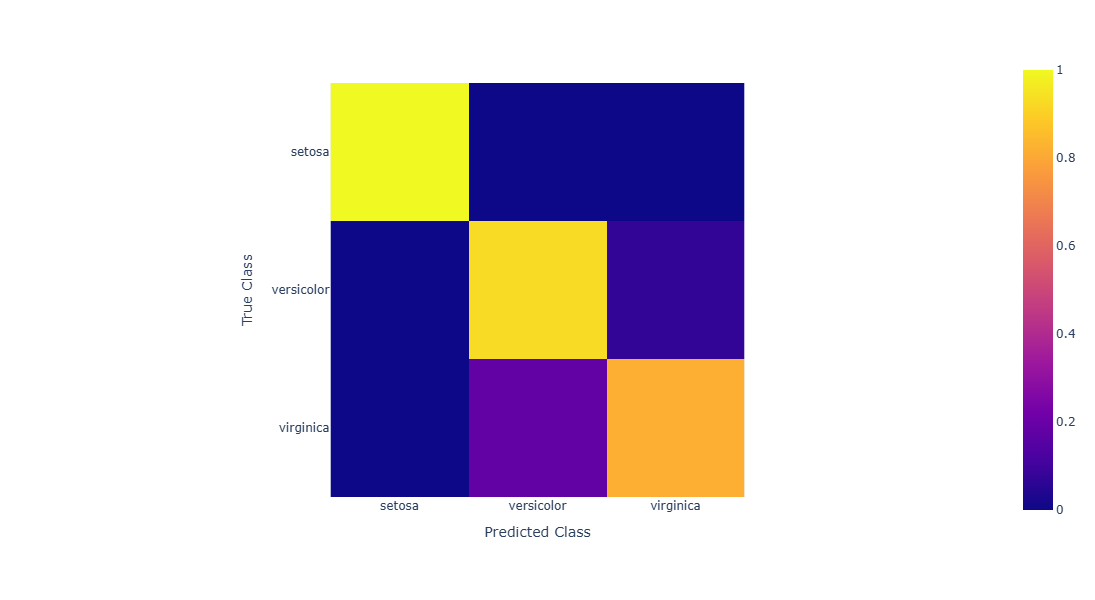

In [239]:
from sklearn.metrics import confusion_matrix

fig = px.imshow(confusion_matrix(y_test, y_pred, normalize = 'true'))

fig.update_layout(
    height = 600, 
    width = 600,
    xaxis = dict(
        tickmode = 'array',
        tickvals = df['species_id'] - 1,
        ticktext = df['species'],
        title = 'Predicted Class'
    ),
    yaxis = dict(
        tickmode = 'array',
        tickvals = df['species_id'] - 1,
        ticktext = df['species'],
        title = 'True Class'
    )
)

fig.show()


(0, 'sepal_length')
(1, 'sepal_width')
(2, 'petal_length')
(3, 'petal_width')



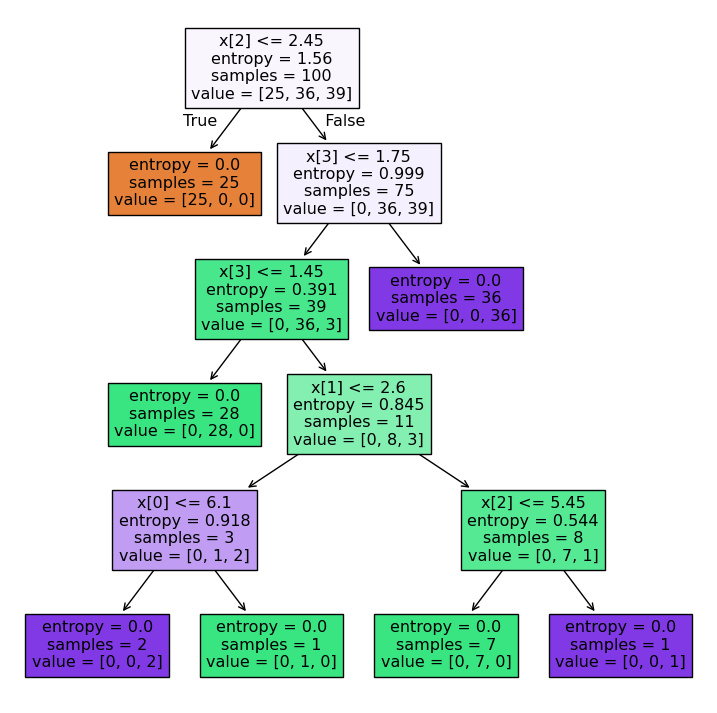

In [240]:
from sklearn.tree import plot_tree

print()
print(*list(enumerate(x_train.columns)), sep = '\n')
print()

plt.figure(figsize = (9, 9))
plot_tree(tree_model, filled = True)
plt.show()

In [246]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(tree_model, x_test, y_test, cv = 5)
print(scores)
print(scores.mean())

[1.  1.  1.  0.9 0.9]
0.96


In [272]:
#https://scikit-learn.org/stable/auto_examples/classification/plot_classifier_comparison.html

from sklearn.metrics import precision_score
from sklearn.metrics import roc_auc_score

from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

import tabulate

model_names = [
    'K Nearest Neighbors',
    'Naive Bayes',
    'SVM',
    'Neural Network',
    'Decision Tree',
    'Random Forest'
]

classifiers = [
    KNeighborsClassifier(5),
    GaussianNB(),
    SVC(kernel = 'linear'),
    MLPClassifier(alpha = 1, max_iter = 1000),
    DecisionTreeClassifier(),
    RandomForestClassifier()
]

data = []

for name, model in zip(model_names, classifiers):
    model.fit(x_train, y_train)
    y_pred = model.predict(x_test)
    
    cv_score = cross_val_score(model, x_test, y_test, cv = 5)

    data.append([
        name, 
        cv_score.mean(), 
        model.score(x_test, y_test), 
        precision_score(y_test, y_pred, average = 'micro'), 
    ])

model_comparison = pd.DataFrame(data)
model_comparison.columns = ['Model', 'Avg Cross-Val Score', 'Accuracy', 'Precision']

model_comparison

,Model,Avg Cross-Val Score,Accuracy,Precision
0,K Nearest Neighbors,0.96,0.96,0.96
1,Naive Bayes,0.94,0.92,0.92
2,SVM,0.94,0.98,0.98
3,Neural Network,0.92,0.98,0.98
4,Decision Tree,0.96,0.94,0.94
5,Random Forest,0.96,0.94,0.94
